In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna(subset=["TotalCharges"]).drop(columns=["customerID"])
df["Churn"] = (df["Churn"] == "Yes").astype(int)
print(df.shape)  # (7032, 20)

(7032, 20)


In [3]:
import os
print(os.getcwd())
print(os.listdir("."))

/home/rajae/churn-prediction
['notebooks', 'src', 'app', '.git', 'README.md', '.ipynb_checkpoints', '.gitignore', 'data', 'venv', '02_modelisation.ipynb']


In [2]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

# One-hot sur les colonnes texte
X = pd.get_dummies(X, drop_first=True)
print(X.shape)

(7032, 30)


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(5625, 30) (1407, 30)


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, roc_auc_score

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, class_weight="balanced")
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("AUC :", round(roc_auc_score(y_test, y_proba), 3))

              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407

AUC : 0.835


In [5]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

rf = RandomForestClassifier(
    n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

# scale_pos_weight = nb negatifs / nb positifs
spw = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    scale_pos_weight=spw, random_state=42, eval_metric="logloss"
)
xgb.fit(X_train, y_train)

for name, m in [("Random Forest", rf), ("XGBoost", xgb)]:
    proba = m.predict_proba(X_test)[:, 1]
    pred = m.predict(X_test)
    print(f"\n=== {name} ===")
    print(classification_report(y_test, pred))
    print("AUC :", round(roc_auc_score(y_test, proba), 3))


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.87      0.81      0.84      1033
           1       0.56      0.66      0.61       374

    accuracy                           0.77      1407
   macro avg       0.72      0.74      0.72      1407
weighted avg       0.79      0.77      0.78      1407

AUC : 0.821

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1033
           1       0.49      0.78      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407

AUC : 0.834


In [6]:
proba_xgb = xgb.predict_proba(X_test)[:, 1]
print("AUC XGBoost :", round(roc_auc_score(y_test, proba_xgb), 3))

AUC XGBoost : 0.834


In [7]:
import shap
import matplotlib.pyplot as plt
import os

os.makedirs("../images", exist_ok=True)

explainer = shap.TreeExplainer(xgb)
shap_values = explainer(X_test)
print(shap_values.shape)

(1407, 30)


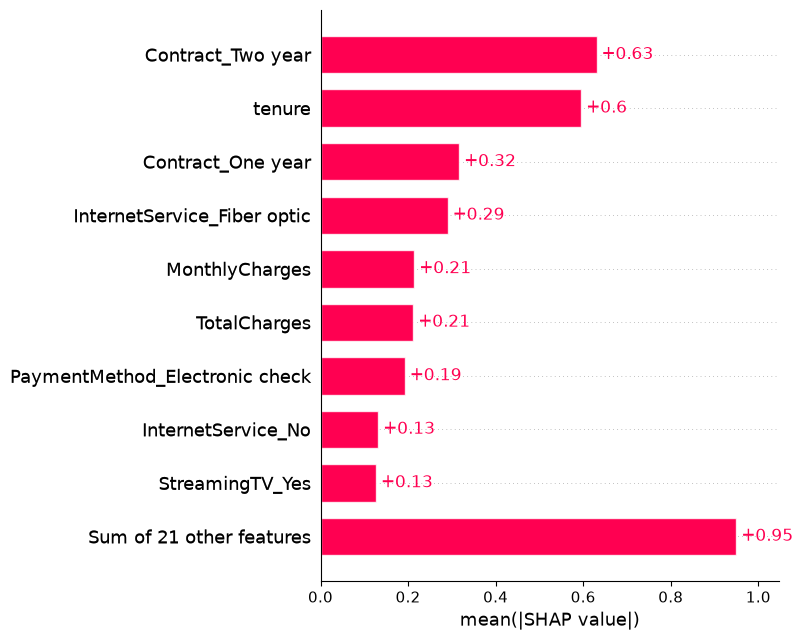

In [8]:
shap.plots.bar(shap_values, max_display=10, show=False)
plt.tight_layout()
plt.savefig("../images/shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

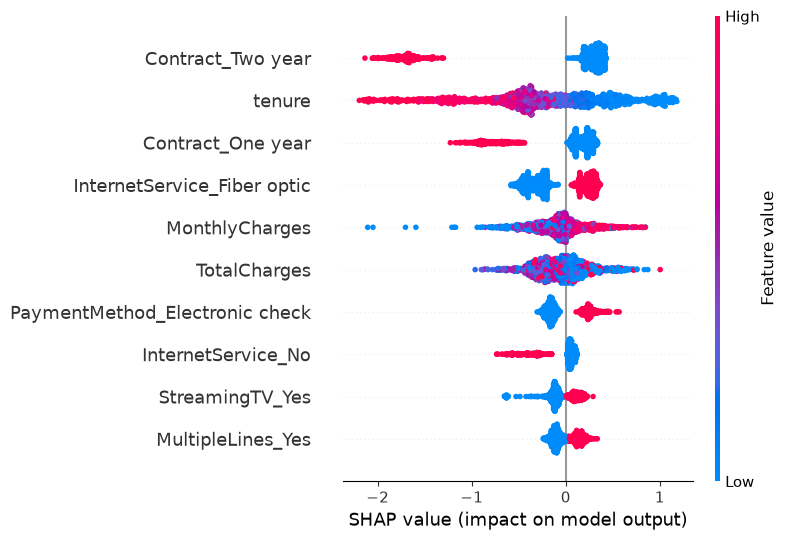

In [9]:
shap.summary_plot(shap_values, X_test, max_display=10, show=False)
plt.tight_layout()
plt.savefig("../images/shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

Probabilité de churn : 0.97


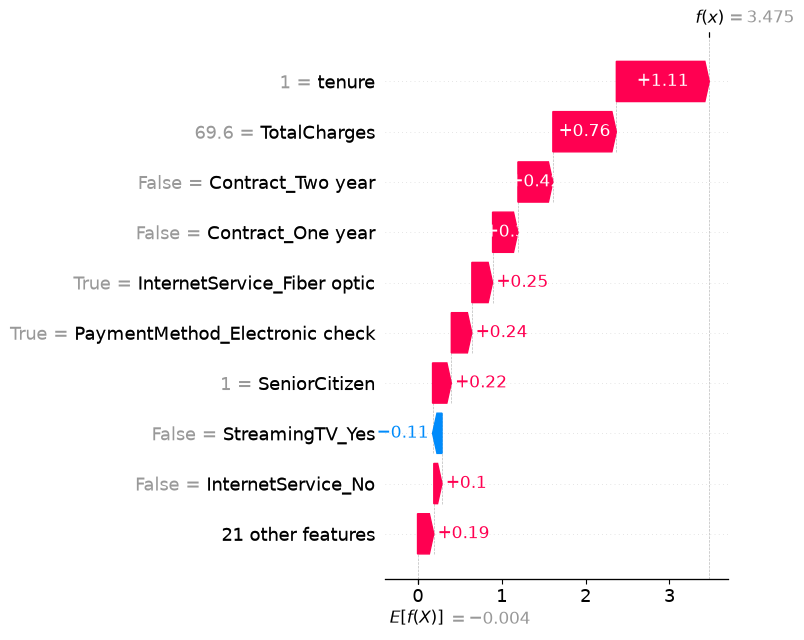

In [10]:
import numpy as np

# Client li 3ndo a3la probabilité de churn
idx = np.argmax(proba_xgb)
print("Probabilité de churn :", round(proba_xgb[idx], 3))

shap.plots.waterfall(shap_values[idx], max_display=10, show=False)
plt.tight_layout()
plt.savefig("../images/shap_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()